# S1–S5: watch features survive or disappear

This notebook isolates **feature selection** from the [full Qbit v2 notebook](harvesting_vrp_synthetic_v2.ipynb).
Run all cells in the project's DEV Python environment. No external data or model fitting is needed.

We use **14 real candidates per day plus SKIP**, with deliberately constructed features that
demonstrate missingness, near-constants, weak relevance, redundancy, group caps, and instability.
These are teaching signals, **not proposed trading features or evidence of predictability**.

The pipeline is:

**training data → S1 missingness → S2 variation → S3 relevance → S4 redundancy/caps
→ S5 time stability → raw selected columns for the ranker.**

Selection is supervised: S3 looks at historical outcomes. It belongs inside each training
boundary, excluding the paper's final six-month confidence-gate holdout and all test data.
Our short example stands in for that already-separated training window; it does not replace
the full notebook's training schedule, label construction, or three optimizations.

Source: [paper, “Feature selection and ranker training”](../../docs/research/papers/Harvesting_the_Volatility_Risk_Premium_A_Learning_to_Rank_Approach.md#feature-selection-and-ranker-training).

| Stage | Paper's rule | Exactly at the boundary |
|---|---|---|
| S1 | Drop real-candidate null rate > 0.30 | 0.30 passes |
| S2 | Drop variance < 1e−6 **or** modal fraction > 0.99 | 1e−6 and 0.99 pass |
| S3 | Drop absolute relevance < 0.05 | ±0.05 passes |
| S4 | Cluster within scope at absolute Spearman ≥ 0.85 | ±0.85 is redundant |
| S4 caps | position 8; vol_surface 4; vix 6; calendar 8; all other groups 5 | Keep up to the cap |
| S5 | Repeat S1–S4 on 3 expanding folds; require ≥ 2 survivals | 2 passes |

We match **v2's reconstruction** where the source is silent: continuous outcome `z` for
relevance, pairwise-complete correlations, sample variance, connected-component clusters,
v2's group-priority order, lower null rate as data-quality tie-breaker, and three equal
entry-date partitions with expanding, outcome-purged prefixes. Undefined relevance is rejected.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from IPython.display import display

pd.set_option('display.max_rows', None)

# Source-defined thresholds/caps, not tuned on this example.
NULL_LIMIT = 0.30
VAR_FLOOR = 1e-6
MODE_LIMIT = 0.99
MIN_RELEVANCE = 0.05
REDUNDANCY = 0.85
CAPS = {'position': 8, 'vol_surface': 4, 'vix': 6, 'calendar': 8}
GROUP_ORDER = ['calendar', 'spx', 'vix', 'vol_surface', 'rv_iv', 'higher_moments',
               'trend', 'position', 'strategy_stats', 'intra_strategy', 'regime']

## 1. The inputs: features, outcomes, and a catalog

`X` has one row per `(date, candidate)`. PS means **candidate-specific**; CS means a
**shared daily context**, copied to every candidate. The catalog assigns each column a scope
and a group. Scope controls how S3/S4 compute correlations; group controls S4's cap and tie order.

We generate features first, then a future outcome `z` from a candidate signal, a common
market state, and independent noise. `z` stands in for v2's continuous P&L-shaped label score.
It is **not a LightGBM prediction or a 0–4 relevance grade**. This notebook does not simulate
option contracts, shape P&L, or estimate the upstream label parameters.

Dates and coefficients below only construct this example. Features are assumed observed at
EOD **t−1** for an entry at EOD **t**; outcomes become known 10 business days later. This simple
clock illustrates the user's holding period without modeling holidays or early expiry.
Ordinary PS features are missing for SKIP; CS context is shared with SKIP; SKIP's outcome is zero.

In [2]:
rng = np.random.default_rng(7)
dates = pd.bdate_range('2020-01-01', '2020-09-30')
selection_cutoff = pd.Timestamp('2020-10-01')
candidates = [f'index_{i:02d}' for i in range(1, 15)] + ['SKIP']
index = pd.MultiIndex.from_product([dates, sorted(candidates)], names=['date', 'candidate'])
row_dates = index.get_level_values('date')
real = index.get_level_values('candidate') != 'SKIP'
real_index = index[real]
real_dates = real_index.get_level_values('date')

signal = rng.normal(size=len(real_index))
market = pd.Series(rng.normal(size=len(dates)), index=dates)
common = market.reindex(real_dates).to_numpy()
toy = pd.DataFrame(index=real_index)
toy['trend_a_signal'] = signal
toy['trend_b_copy'] = 100 * signal + 10  # Different units, identical ordering.
toy['trend_c_inverse'] = -signal        # Negative relevance still matters.
for i in range(1, 7):
    toy[f'trend_component_{i}'] = signal + 1.5 * rng.normal(size=len(signal))
toy['tiny_units'] = signal * 1e-4
toy['missing_40pct'] = np.where(np.arange(len(signal)) % 10 < 4, np.nan, signal)
toy['constant'] = 1.0
toy['almost_constant'] = 0.0
toy.loc[real_index[:3], 'almost_constant'] = 1.0
toy['random_noise'] = rng.normal(size=len(signal))
toy['shared_but_tagged_PS'] = common
toy['market_a_state'] = common
toy['market_b_inverse'] = -common

# Deliberately change one feature's cross-sectional behavior in the last third.
eligible_dates = dates[dates + pd.offsets.BDay(10) < selection_cutoff]
late_start = np.array_split(eligible_dates, 3)[2][0]
toy['late_feature'] = np.where(real_dates >= late_start, signal, common)

X = toy.reindex(index)
catalog = pd.DataFrame({'scope': 'PS', 'group': 'trend'}, index=X.columns)
catalog.loc[['market_a_state', 'market_b_inverse'], ['scope', 'group']] = ['CS', 'spx']
catalog.loc['late_feature', 'group'] = 'position'
catalog['sources'] = catalog['group'].map(lambda group: {group})
for feature in catalog.index[catalog.scope == 'CS']:
    X[feature] = toy[feature].groupby(level='date').first().reindex(row_dates).to_numpy()

panel = pd.DataFrame(index=index)
panel['observed_at'] = row_dates - pd.offsets.BDay(1)
panel['label_available'] = row_dates + pd.offsets.BDay(10)
panel['z'] = 0.0
panel.loc[real, 'z'] = signal + 2 * common + 0.6 * rng.normal(size=len(signal))
display(catalog[['scope', 'group']])
display(X.join(panel).loc[dates[0], ['trend_a_signal', 'market_a_state',
                                   'z', 'observed_at', 'label_available']])

,scope,group
trend_a_signal,PS,trend
trend_b_copy,PS,trend
trend_c_inverse,PS,trend
trend_component_1,PS,trend
trend_component_2,PS,trend
trend_component_3,PS,trend
trend_component_4,PS,trend
trend_component_5,PS,trend
trend_component_6,PS,trend
tiny_units,PS,trend


,trend_a_signal,market_a_state,z,observed_at,label_available
candidate,,,,,
SKIP,NaN,-0.607782,0.000000,2019-12-31,2020-01-15
index_01,0.001230,-0.607782,-0.280141,2019-12-31,2020-01-15
index_02,0.298746,-0.607782,-1.068882,2019-12-31,2020-01-15
index_03,-0.274138,-0.607782,-1.376859,2019-12-31,2020-01-15
index_04,-0.890592,-0.607782,-1.337812,2019-12-31,2020-01-15
index_05,-0.454671,-0.607782,-1.691949,2019-12-31,2020-01-15
index_06,-0.991647,-0.607782,-2.126354,2019-12-31,2020-01-15
index_07,0.060144,-0.607782,-1.488051,2019-12-31,2020-01-15
index_08,1.340215,-0.607782,0.425985,2019-12-31,2020-01-15


### The prepared-data boundary

Everything below consumes just **`X`, `panel`, `catalog`, and `selection_cutoff`**.
To inspect real selection, replace the generation cell above with these prepared objects
from v2. Keep the `(date, candidate)` index identical and sorted; columns must be numeric
and finite or NaN; CS values must agree within each date. The catalog needs each feature's
`scope` and `group` (`sources` is included for v2 parity). `panel` needs continuous `z`,
`observed_at`, and `label_available` aligned to every row.

Use features already aligned to t−1 **once**. Use outcomes and label-shaping parameters
available to that training fit; a column called `z` does not by itself guarantee this.
The cutoff is the start of the gate holdout, not the eventual test date. This teaching
notebook does not reconstruct a raw Qbit loader; v2 provides that earlier data boundary.

We first remove entire daily queries with unavailable outcomes, then exclude SKIP when
computing all selection statistics. Missing SKIP descriptors must not inflate S1's null rate.

In [3]:
row_dates = X.index.get_level_values('date')
real = X.index.get_level_values('candidate') != 'SKIP'
assert X.index.equals(panel.index) and X.index.is_unique and X.index.is_monotonic_increasing
assert set(X.columns) == set(catalog.index)
assert catalog.scope.isin(['PS', 'CS']).all() and catalog.group.isin(GROUP_ORDER).all()
assert not np.isinf(X.to_numpy()).any()
assert (panel.observed_at < row_dates).all()
cs_columns = catalog.index[catalog.scope == 'CS']
assert X[cs_columns].groupby(level='date').nunique(dropna=False).le(1).all().all()

known = panel.z.notna() & panel.label_available.lt(selection_cutoff)
query_known = known.groupby(level='date').transform('all').to_numpy()
selection_mask = (row_dates < selection_cutoff) & query_known
frame = X.loc[selection_mask & real]
target = panel.loc[frame.index, 'z']
training_dates = row_dates[selection_mask].unique().sort_values()
display(pd.Series({
    'entry dates supplied': row_dates.nunique(),
    'entry dates eligible': len(training_dates),
    'real rows for statistics': len(frame),
    'SKIP rows excluded from statistics': int((selection_mask & ~real).sum()),
    'first eligible entry': training_dates[0],
    'last eligible entry': training_dates[-1],
    'latest eligible outcome': panel.loc[selection_mask, 'label_available'].max(),
    'selection cutoff (exclusive)': selection_cutoff,
}, name='Training boundary'))

entry dates supplied                                  196
entry dates eligible                                  186
real rows for statistics                             2604
SKIP rows excluded from statistics                    186
first eligible entry                  2020-01-01 00:00:00
last eligible entry                   2020-09-16 00:00:00
latest eligible outcome               2020-09-30 00:00:00
selection cutoff (exclusive)          2020-10-01 00:00:00
Name: Training boundary, dtype: object

## 2. S1 — is enough data present?

For each column, divide its number of missing observations by the number of **real-candidate
training rows**. Drop only when this exceeds 30%. No imputation or zero filling occurs.
The threshold counts rows, not the percentage of dates with any missing candidate.

In [4]:
def s1(data):
    audit = pd.DataFrame({'null_rate': data.isna().mean()})
    audit['reason'] = np.where(audit.null_rate > NULL_LIMIT, 'S1 missingness', 'kept')
    return audit


audit = s1(frame)
display(audit.sort_values('null_rate', ascending=False))

,null_rate,reason
missing_40pct,0.400922,S1 missingness
trend_a_signal,0.000000,kept
trend_b_copy,0.000000,kept
market_b_inverse,0.000000,kept
market_a_state,0.000000,kept
shared_but_tagged_PS,0.000000,kept
random_noise,0.000000,kept
almost_constant,0.000000,kept
constant,0.000000,kept
tiny_units,0.000000,kept


## 3. S2 — does it vary?

Two separate failure modes: variance below 1e−6, **or** a single value making up more
than 99% of observed rows. NaNs are omitted from both calculations; variance uses `ddof=1`.
We calculate metrics for every feature but preserve the first rejection reason.

`constant` fails both tests. `almost_constant` has a few spikes: enough variance, but too
many identical values. `tiny_units` has exactly the same ordering as `trend_a_signal`,
yet fails the variance floor. **This rule depends on units.** We keep the paper's rule
visible rather than silently standardizing before it.

In [5]:
def s2(data, audit):
    audit = audit.copy()
    audit['variance'] = data.var()
    audit['modal_fraction'] = data.apply(lambda column: column.value_counts(normalize=True).max())
    fail = (audit.variance < VAR_FLOOR) | (audit.modal_fraction > MODE_LIMIT)
    audit.loc[audit.reason.eq('kept') & fail, 'reason'] = 'S2 near-constant'
    return audit


audit = s2(frame, audit)
display(audit[['null_rate', 'variance', 'modal_fraction', 'reason']])

,null_rate,variance,modal_fraction,reason
trend_a_signal,0.000000,9.788919e-01,0.000384,kept
trend_b_copy,0.000000,9.788919e+03,0.000384,kept
trend_c_inverse,0.000000,9.788919e-01,0.000384,kept
trend_component_1,0.000000,3.322864e+00,0.000384,kept
trend_component_2,0.000000,3.045018e+00,0.000384,kept
trend_component_3,0.000000,3.417518e+00,0.000384,kept
trend_component_4,0.000000,3.234472e+00,0.000384,kept
trend_component_5,0.000000,3.119564e+00,0.000384,kept
trend_component_6,0.000000,3.009240e+00,0.000384,kept
tiny_units,0.000000,9.788919e-09,0.000384,S2 near-constant


## 4. S3 — is there a directional relationship with the outcome?

**PS:** within each day, rank the observed `(feature, z)` pairs, compute their Spearman
correlation, then take the **median of the defined daily correlations**. Each defined day
has equal weight. Missing pairs are removed *before* ranking; tied values receive average ranks.
A constant feature or outcome on a day makes that day's correlation undefined.

**CS:** take one feature value per day and the mean real-candidate outcome for that day;
compute one Spearman correlation **across dates**. There is no daily cross-sectional
correlation for a feature shared by all candidates.

In either case, keep absolute relevance ≥ 0.05. Negative correlations can be useful:
the ranker can learn that smaller values are preferable. This is a univariate screen,
not model importance; a feature useful only through a nonlinear interaction can fail it.

### One day's PS calculation, by hand

Spearman is Pearson correlation of ranks:
`sum(centered_x_rank * centered_z_rank) / sqrt(sum(centered_x_rank²) * sum(centered_z_rank²))`.
The table below shows every candidate's contribution. This ranking is temporary: it does
**not** replace the raw feature values supplied to LightGBM later.

In [6]:
example_day = training_dates[0]
worked = frame.loc[example_day, ['trend_a_signal']].join(target.loc[example_day]).dropna()
worked.columns = ['x', 'z']
worked[['x_rank', 'z_rank']] = worked[['x', 'z']].rank().to_numpy()
worked['dx'] = worked.x_rank - worked.x_rank.mean()
worked['dz'] = worked.z_rank - worked.z_rank.mean()
worked['dx_times_dz'] = worked.dx * worked.dz
manual_ic = worked.dx_times_dz.sum() / np.sqrt(worked.dx.pow(2).sum() * worked.dz.pow(2).sum())
display(worked)
print(f'{example_day.date()}: manual Spearman = {manual_ic:.6f}')
print(f'Pandas Spearman = {worked.x.corr(worked.z, method="spearman"):.6f}')

,x,z,x_rank,z_rank,dx,dz,dx_times_dz
candidate,,,,,,,
index_01,0.001230,-0.280141,8.0,13.0,0.5,5.5,2.75
index_02,0.298746,-1.068882,11.0,9.0,3.5,1.5,5.25
index_03,-0.274138,-1.376859,7.0,6.0,-0.5,-1.5,0.75
index_04,-0.890592,-1.337812,3.0,7.0,-4.5,-0.5,2.25
index_05,-0.454671,-1.691949,6.0,4.0,-1.5,-3.5,5.25
index_06,-0.991647,-2.126354,1.0,3.0,-6.5,-4.5,29.25
index_07,0.060144,-1.488051,9.0,5.0,1.5,-2.5,-3.75
index_08,1.340215,0.425985,14.0,14.0,6.5,6.5,42.25
index_09,-0.492207,-1.303921,5.0,8.0,-2.5,0.5,-1.25


2020-01-01: manual Spearman = 0.806593


Pandas Spearman = 0.806593


In [7]:
def s3(data, outcomes, audit):
    audit = audit.copy()
    audit['relevance'] = np.nan
    daily_ic = {}
    for feature in audit.index[audit.reason.eq('kept')]:
        if catalog.at[feature, 'scope'] == 'CS':
            daily_x = data[feature].groupby(level='date').first()
            daily_z = outcomes.groupby(level='date').mean()
            value = daily_x.corr(daily_z, method='spearman')
        else:
            pairs = pd.concat([data[feature].rename('x'), outcomes.rename('z')], axis=1).dropna()
            ranks = pairs.groupby(level='date').rank(method='average')
            centered = ranks - ranks.groupby(level='date').transform('mean')
            numerator = (centered.x * centered.z).groupby(level='date').sum()
            denominator = np.sqrt(centered.x.pow(2).groupby(level='date').sum()
                                  * centered.z.pow(2).groupby(level='date').sum())
            daily_ic[feature] = numerator / denominator.replace(0, np.nan)
            defined = daily_ic[feature].dropna()
            value = defined.median() if not defined.empty else np.nan
        audit.at[feature, 'relevance'] = value
    weak = audit.relevance.isna() | (audit.relevance.abs() < MIN_RELEVANCE)
    audit.loc[audit.reason.eq('kept') & weak, 'reason'] = 'S3 relevance'
    return audit, pd.DataFrame(daily_ic)


audit, daily_ic = s3(frame, target, audit)
display(audit[['relevance', 'reason']].join(catalog[['scope']]))
display(pd.DataFrame({'defined days': daily_ic.count(),
                      'median daily IC': audit.relevance.reindex(daily_ic.columns)}))

,relevance,reason,scope
trend_a_signal,0.839560,kept,PS
trend_b_copy,0.839560,kept,PS
trend_c_inverse,-0.839560,kept,PS
trend_component_1,0.483516,kept,PS
trend_component_2,0.490110,kept,PS
trend_component_3,0.454945,kept,PS
trend_component_4,0.485714,kept,PS
trend_component_5,0.428571,kept,PS
trend_component_6,0.435165,kept,PS
tiny_units,NaN,S2 near-constant,PS


,defined days,median daily IC
trend_a_signal,186,0.839560
trend_b_copy,186,0.839560
trend_c_inverse,186,-0.839560
trend_component_1,186,0.483516
trend_component_2,186,0.490110
trend_component_3,186,0.454945
trend_component_4,186,0.485714
trend_component_5,186,0.428571
trend_component_6,186,0.435165
random_noise,186,-0.008791


### Shared values need CS treatment

`shared_but_tagged_PS` deliberately has the wrong scope: every candidate has the same value
on a date, so all its PS daily correlations are undefined and v2 rejects it. The identical
numbers tagged CS as `market_a_state` are evaluated across dates and pass in this example.
Scope is an economic definition of the feature, **not a setting to optimize for survival**.

The inverse feature has relevance equal in magnitude and opposite in sign to the original.
S3 keeps both. S4 will ask whether keeping both provides distinct information.

Notice `late_feature`: early daily correlations are undefined, but its full-window median
uses the defined late dates. It passes S3 despite not having useful cross-sectional variation
throughout the history. We will watch S5 reject it.

,market_a_state,day_mean_z,feature_rank,outcome_rank
date,,,,
2020-01-01,-0.607782,-1.187664,66.0,61.0
2020-01-02,-1.552411,-3.857265,12.0,7.0
2020-01-03,-1.170543,-2.496526,21.0,19.0
2020-01-06,-0.480462,-0.972659,72.0,73.0
2020-01-07,-0.219626,-0.342420,88.0,92.0


CS correlation uses all eligible dates: 0.985058441225424


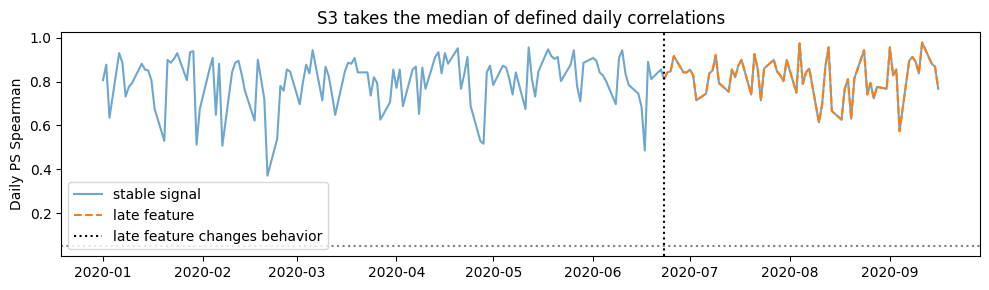

In [8]:
cs_example = pd.DataFrame({
    'market_a_state': frame.market_a_state.groupby(level='date').first(),
    'day_mean_z': target.groupby(level='date').mean(),
})
cs_example[['feature_rank', 'outcome_rank']] = cs_example.rank().to_numpy()
display(cs_example.head())
print('CS correlation uses all eligible dates:',
      cs_example.market_a_state.corr(cs_example.day_mean_z, method='spearman'))

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(daily_ic.index, daily_ic.trend_a_signal, label='stable signal', alpha=0.65)
ax.plot(daily_ic.index, daily_ic.late_feature, label='late feature', linestyle='--')
ax.axvline(late_start, color='black', linestyle=':', label='late feature changes behavior')
ax.axhline(MIN_RELEVANCE, color='gray', linestyle=':')
ax.set(ylabel='Daily PS Spearman', title='S3 takes the median of defined daily correlations')
ax.legend(loc='lower left')
fig.tight_layout()
plt.show()

## 5. S4 — keep representatives, then apply group caps

Among S3 survivors, compute pairwise-complete feature–feature Spearman correlations.
For **PS**, v2 pools real-candidate rows across dates; this is not S3's median daily IC.
For **CS**, use one row per date. Never cluster PS and CS together.

Connect two columns when |correlation| ≥ 0.85, then find connected components. A chain
`A—B—C` is one cluster even if A and C themselves have correlation below 0.85.
**Connected components is v2's choice; the paper does not specify the linkage.**

Each cluster keeps the feature ordered first by:

1. Largest absolute S3 relevance.
2. Earliest catalog group in `GROUP_ORDER` (v2's reconstruction).
3. Lower training null rate.
4. Alphabetical feature name.

Then, within each group, keep only up to the paper's cap using the same ordering.
Redundancy works across groups within a scope; the subsequent caps work by group across scopes.
Undefined feature–feature correlations create no edge; they do not cause any filling of `X`.

In [9]:
def s4(data, audit):
    audit = audit.copy()

    def priority(feature):
        return (-abs(audit.at[feature, 'relevance']),
                GROUP_ORDER.index(catalog.at[feature, 'group']),
                audit.at[feature, 'null_rate'], feature)

    clusters, cap_rows, correlations = [], [], {}
    for scope in ['CS', 'PS']:
        columns = [c for c in audit.index[audit.reason.eq('kept')]
                   if catalog.at[c, 'scope'] == scope]
        if not columns:
            continue
        values = data[columns]
        if scope == 'CS':
            values = values.groupby(level='date').first()
        correlations[scope] = values.corr(method='spearman')
        adjacency = correlations[scope].abs().fillna(0).to_numpy() >= REDUNDANCY
        np.fill_diagonal(adjacency, True)
        _, labels = connected_components(csr_matrix(adjacency), directed=False)
        for label in np.unique(labels):
            members = [c for c, component in zip(columns, labels) if component == label]
            winner = min(members, key=priority)
            for feature in members:
                clusters.append({'scope': scope, 'cluster': f'{scope}-{label}',
                                 'feature': feature, 'winner': winner})
                if feature != winner:
                    audit.at[feature, 'reason'] = 'S4 redundancy'
    for group in GROUP_ORDER:
        members = [c for c in audit.index[audit.reason.eq('kept')]
                   if catalog.at[c, 'group'] == group]
        for rank, feature in enumerate(sorted(members, key=priority), start=1):
            cap = CAPS.get(group, 5)
            cap_rows.append({'group': group, 'feature': feature, 'priority_rank': rank,
                             'cap': cap, 'within_cap': rank <= cap})
            if rank > cap:
                audit.at[feature, 'reason'] = 'S4 group cap'
    return audit, pd.DataFrame(clusters), pd.DataFrame(cap_rows), correlations


audit, clusters, cap_table, correlations = s4(frame, audit)
display(clusters.merge(audit[['relevance', 'null_rate', 'reason']],
                       left_on='feature', right_index=True))
display(cap_table)

,scope,cluster,feature,winner,relevance,null_rate,reason
0,CS,CS-0,market_a_state,market_a_state,0.985058,0.0,kept
1,CS,CS-0,market_b_inverse,market_a_state,-0.985058,0.0,S4 redundancy
2,PS,PS-0,trend_a_signal,trend_a_signal,0.839560,0.0,kept
3,PS,PS-0,trend_b_copy,trend_a_signal,0.839560,0.0,S4 redundancy
4,PS,PS-0,trend_c_inverse,trend_a_signal,-0.839560,0.0,S4 redundancy
5,PS,PS-1,trend_component_1,trend_component_1,0.483516,0.0,kept
6,PS,PS-2,trend_component_2,trend_component_2,0.490110,0.0,kept
7,PS,PS-3,trend_component_3,trend_component_3,0.454945,0.0,kept
8,PS,PS-4,trend_component_4,trend_component_4,0.485714,0.0,kept
9,PS,PS-5,trend_component_5,trend_component_5,0.428571,0.0,S4 group cap


,group,feature,priority_rank,cap,within_cap
0,spx,market_a_state,1,5,True
1,trend,trend_a_signal,1,5,True
2,trend,trend_component_2,2,5,True
3,trend,trend_component_4,3,5,True
4,trend,trend_component_1,4,5,True
5,trend,trend_component_3,5,5,True
6,trend,trend_component_6,6,5,False
7,trend,trend_component_5,7,5,False
8,position,late_feature,1,8,True


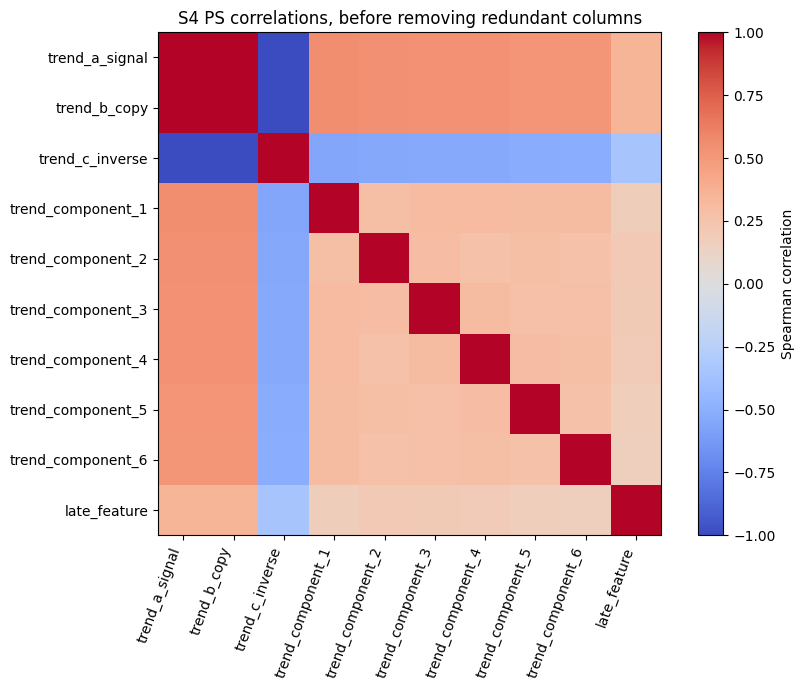

,relevance,null_rate,reason
trend_a_signal,0.83956,0.0,kept
trend_b_copy,0.83956,0.0,S4 redundancy
trend_c_inverse,-0.83956,0.0,S4 redundancy


Full-window S1–S4 survivors: ['trend_a_signal', 'trend_component_1', 'trend_component_2', 'trend_component_3', 'trend_component_4', 'market_a_state', 'late_feature']


In [10]:
# Plot signed correlations: both strongly positive and strongly negative pairs cluster.
corr = correlations['PS']
fig, ax = plt.subplots(figsize=(9, 7))
plot = ax.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(len(corr)), corr.columns, rotation=70, ha='right')
ax.set_yticks(range(len(corr)), corr.index)
ax.set_title('S4 PS correlations, before removing redundant columns')
fig.colorbar(plot, ax=ax, label='Spearman correlation')
fig.tight_layout()
plt.show()

display(audit.loc[['trend_a_signal', 'trend_b_copy', 'trend_c_inverse'],
                  ['relevance', 'null_rate', 'reason']])
print('Full-window S1–S4 survivors:', audit.index[audit.reason.eq('kept')].tolist())

`trend_a_signal`, its positive rescaling, and its inverse all carry the same ordering
information. Their absolute relevance, group and missingness tie, so the alphabetical
name selects `trend_a_signal`. No averaging, PCA, or new combined feature is created.

The six noisy components can be individually relevant without being correlated enough
to form the same cluster. The trend cap is **five**, so S4 also removes otherwise acceptable
representatives from this deliberately overpopulated group. Changing the random example
can change which components win; it does not change the cap.

## 6. S5 — does the feature survive at different points in history?

Now repeat **all of S1–S4**, recomputing every metric, cluster, and cap on each earlier prefix.
V2 divides eligible entry dates into three equal consecutive partitions and uses each
partition's last date as an expanding fold endpoint. Fold 2 includes fold 1; fold 3 includes both.

At each endpoint, purge entire queries whose outcomes are not yet available. Consequently,
the third fold can contain fewer usable entries than the full selection window: full-window
selection uses its later selection cutoff, while fold 3 uses its last entry date as the cutoff.
Both are shown below. Equality at the fold endpoint is allowed, matching v2.

These are **stability screens, not train/validation splits or out-of-sample model scores**.
A feature must survive full-window S1–S4 **and** at least two of the three repeats.
Survival in two folds cannot resurrect a feature rejected by full-window S1–S4.

In [11]:
def run_s1_s4(data, outcomes):
    result = s2(data, s1(data))
    result, _ = s3(data, outcomes, result)
    result, _, _, _ = s4(data, result)
    return result


fold_reasons = pd.DataFrame(index=X.columns)
fold_timeline = []
for number, partition in enumerate(np.array_split(training_dates, 3), start=1):
    end = partition[-1]
    available = panel.z.notna() & panel.label_available.le(end)
    available = available.groupby(level='date').transform('all').to_numpy()
    fold_mask = selection_mask & (row_dates <= end) & available
    fold_frame = X.loc[fold_mask & real]
    fold_target = panel.loc[fold_frame.index, 'z']
    fold_audit = run_s1_s4(fold_frame, fold_target)
    fold_reasons[f'fold_{number}'] = fold_audit.reason
    fold_timeline.append({
        'fold': number, 'prefix_end': end,
        'entry_dates_before_purge': row_dates[selection_mask & (row_dates <= end)].nunique(),
        'entry_dates_used': fold_frame.index.get_level_values('date').nunique(),
        'first_entry_used': fold_frame.index.get_level_values('date').min(),
        'last_entry_used': fold_frame.index.get_level_values('date').max(),
        'latest_outcome_used': panel.loc[fold_mask, 'label_available'].max(),
    })

fold_timeline = pd.DataFrame(fold_timeline).set_index('fold')
final_audit = audit.copy()
final_audit['fold_survival'] = fold_reasons.eq('kept').sum(axis=1)
unstable = final_audit.reason.eq('kept') & final_audit.fold_survival.lt(2)
final_audit.loc[unstable, 'reason'] = 'S5 unstable'
selected = final_audit.index[final_audit.reason.eq('kept')].tolist()
display(fold_timeline)
display(fold_reasons.join(final_audit[['fold_survival', 'reason']]))

,prefix_end,entry_dates_before_purge,entry_dates_used,first_entry_used,last_entry_used,latest_outcome_used
fold,,,,,,
1,2020-03-26,62,52,2020-01-01,2020-03-12,2020-03-26
2,2020-06-22,124,114,2020-01-01,2020-06-08,2020-06-22
3,2020-09-16,186,176,2020-01-01,2020-09-02,2020-09-16


,fold_1,fold_2,fold_3,fold_survival,reason
trend_a_signal,kept,kept,kept,3,kept
trend_b_copy,S4 redundancy,S4 redundancy,S4 redundancy,0,S4 redundancy
trend_c_inverse,S4 redundancy,S4 redundancy,S4 redundancy,0,S4 redundancy
trend_component_1,kept,kept,kept,3,kept
trend_component_2,S4 group cap,kept,kept,2,kept
trend_component_3,kept,kept,kept,3,kept
trend_component_4,kept,kept,kept,3,kept
trend_component_5,S4 group cap,S4 group cap,S4 group cap,0,S4 group cap
trend_component_6,kept,S4 group cap,S4 group cap,1,S4 group cap
tiny_units,S2 near-constant,S2 near-constant,S2 near-constant,0,S2 near-constant


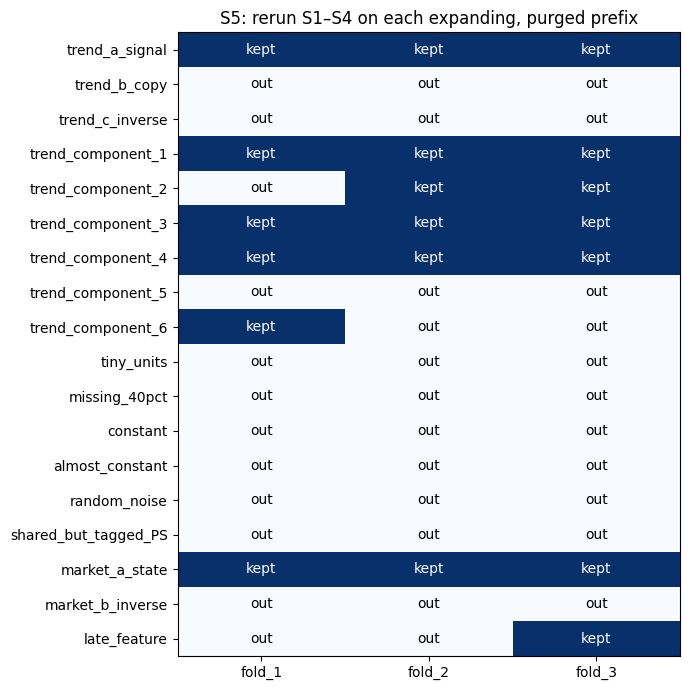

In [12]:
survival = fold_reasons.eq('kept').astype(int)
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(survival, vmin=0, vmax=1, cmap='Blues', aspect='auto')
ax.set_xticks(range(3), survival.columns)
ax.set_yticks(range(len(survival)), survival.index)
for row, feature in enumerate(survival.index):
    for column in range(3):
        kept = survival.iloc[row, column]
        ax.text(column, row, 'kept' if kept else 'out', ha='center', va='center',
                color='white' if kept else 'black')
ax.set_title('S5: rerun S1–S4 on each expanding, purged prefix')
fig.tight_layout()
plt.show()

The `late_feature` deliberately has no within-day variation in the early history. It passes
full-window S3 once informative days appear, but only survives the last stability fold.
S5 rejects it for surviving **1/3**, below the required **2/3**.

A stable underlying noisy feature can also lose a fold because a competing column wins
that fold's group cap. S5 measures stability of the **whole selection procedure**, not just
whether the sign of correlation stays the same. The per-fold reason table makes this visible.

## 7. The result: selected columns, still raw

The table below records the **first rejecting stage** for every input feature. A missing
relevance value can mean S1/S2 rejected the feature before S3 ran, or that S3 could not
calculate it; use the reason column to distinguish those cases.

`X_selected` is just a column subset of the original matrix, including SKIP's original
missing values. Apply this frozen column list to the later gate/test matrices too; do not
reselect on their outcomes. The ranker then learns from the selected features and the
training relevance grades in a separate step.

In [13]:
decision_table = catalog[['scope', 'group']].join(final_audit)
display(decision_table)
print('Final selected features:', selected)
X_selected = X.loc[:, selected].copy()
display(X_selected.loc[training_dates[0]])
display(final_audit.reason.value_counts().rename('number of features'))

,scope,group,null_rate,reason,variance,modal_fraction,relevance,fold_survival
trend_a_signal,PS,trend,0.000000,kept,9.788919e-01,0.000384,0.839560,3
trend_b_copy,PS,trend,0.000000,S4 redundancy,9.788919e+03,0.000384,0.839560,0
trend_c_inverse,PS,trend,0.000000,S4 redundancy,9.788919e-01,0.000384,-0.839560,0
trend_component_1,PS,trend,0.000000,kept,3.322864e+00,0.000384,0.483516,3
trend_component_2,PS,trend,0.000000,kept,3.045018e+00,0.000384,0.490110,2
trend_component_3,PS,trend,0.000000,kept,3.417518e+00,0.000384,0.454945,3
trend_component_4,PS,trend,0.000000,kept,3.234472e+00,0.000384,0.485714,3
trend_component_5,PS,trend,0.000000,S4 group cap,3.119564e+00,0.000384,0.428571,0
trend_component_6,PS,trend,0.000000,S4 group cap,3.009240e+00,0.000384,0.435165,1
tiny_units,PS,trend,0.000000,S2 near-constant,9.788919e-09,0.000384,NaN,0


Final selected features: ['trend_a_signal', 'trend_component_1', 'trend_component_2', 'trend_component_3', 'trend_component_4', 'market_a_state']


,trend_a_signal,trend_component_1,trend_component_2,trend_component_3,trend_component_4,market_a_state
candidate,,,,,,
SKIP,NaN,NaN,NaN,NaN,NaN,-0.607782
index_01,0.001230,2.052153,-1.008530,-1.631342,-0.697183,-0.607782
index_02,0.298746,0.760866,-0.443967,1.245209,1.368270,-0.607782
index_03,-0.274138,-0.621777,-0.251927,0.054192,0.363596,-0.607782
index_04,-0.890592,0.888912,0.886010,2.251723,0.248153,-0.607782
index_05,-0.454671,-1.036062,-2.988876,2.184625,-0.262348,-0.607782
index_06,-0.991647,-1.411310,-0.798755,-0.106649,0.617194,-0.607782
index_07,0.060144,-0.631614,-3.257745,1.049306,0.230702,-0.607782
index_08,1.340215,-1.602294,-0.228580,-1.276642,2.788544,-0.607782


reason
kept                6
S4 redundancy       3
S2 near-constant    3
S4 group cap        2
S3 relevance        2
S1 missingness      1
S5 unstable         1
Name: number of features, dtype: int64

## 8. Compact checks

These assertions pin down this deterministic teaching example: each rejection mechanism
appears, negative relevance is preserved until redundancy selection, the hand calculation
agrees, and the final matrix retains raw inputs. They also check the exact inclusive/exclusive
boundaries and that no fold uses an outcome from after its endpoint.

In [14]:
expected_reasons = {
    'missing_40pct': 'S1 missingness',
    'constant': 'S2 near-constant',
    'almost_constant': 'S2 near-constant',
    'tiny_units': 'S2 near-constant',
    'shared_but_tagged_PS': 'S3 relevance',
    'trend_b_copy': 'S4 redundancy',
    'trend_c_inverse': 'S4 redundancy',
    'market_b_inverse': 'S4 redundancy',
    'late_feature': 'S5 unstable',
}
for feature, reason in expected_reasons.items():
    assert final_audit.at[feature, 'reason'] == reason, (feature, final_audit.loc[feature])
assert final_audit.reason.eq('S4 group cap').any()
assert final_audit.at['late_feature', 'fold_survival'] == 1
assert np.isclose(manual_ic, daily_ic.at[example_day, 'trend_a_signal'])
assert np.isclose(audit.at['trend_a_signal', 'relevance'],
                  -audit.at['trend_c_inverse', 'relevance'])
assert (final_audit.loc[selected, 'fold_survival'] >= 2).all()
assert (fold_timeline.latest_outcome_used <= fold_timeline.prefix_end).all()
assert panel.loc[selection_mask, 'label_available'].lt(selection_cutoff).all()
assert frame.index.get_level_values('candidate').isin(['SKIP']).sum() == 0
for group, count in catalog.loc[selected].groupby('group').size().items():
    assert count <= CAPS.get(group, 5)
pd.testing.assert_frame_equal(X_selected, X[selected])

# Test comparisons at the source-defined numerical boundaries using small series.
assert not (pd.Series([0.30]) > NULL_LIMIT).iloc[0]
assert not (pd.Series([1e-6]) < VAR_FLOOR).iloc[0]
assert not (pd.Series([0.99]) > MODE_LIMIT).iloc[0]
assert (pd.Series([-0.05, 0.05]).abs() >= MIN_RELEVANCE).all()
assert (pd.Series([-0.85, 0.85]).abs() >= REDUNDANCY).all()
assert (pd.Series([1, 2, 3]) >= 2).tolist() == [False, True, True]
print('All S1–S5 walkthrough checks passed.')

All S1–S5 walkthrough checks passed.


### What this selection does—and does not—establish

- It removes columns for explicit, inspectable reasons. It does not rank their economic value.
- Spearman correlations use ranks internally; the selected model inputs remain raw.
- S2 depends on feature units; S3 can miss relationships that appear only through interactions;
  S4's graph can join a chain of partially redundant features.
- Three expanding prefixes share observations. Passing S5 is not evidence of independent
  out-of-sample performance; model tuning, gate calibration, and held-out testing still follow.

Continue with the [lighter train → tune → gate → test notebook](harvesting_vrp_trend_walkthrough.ipynb)
to see where this selected matrix fits in the full process. Use [v2](harvesting_vrp_synthetic_v2.ipynb)
for the complete feature catalog and Qbit data preparation.